In [22]:
import numpy as np

def parse_atc_code(code):
   #level2
    level1 = code[:3]   
    #level3
    level2 = code[:4] 
    #levl4
    level3 = code[:5]           
    return (level1, level2, level3)



In [23]:
def atc_code_similarity(a, b):
    weights = [1, 2, 4] #weights
    score = 0
    for r in range(3):
            if r < len(a) and r < len(b) and a[r] == b[r]: #codes the same lenght?
                score += weights[r]  
    return score / 7  

def drug_atc_similarity(drug_p_code, drug_q_code):
    
    
    P = [parse_atc_code(c) for c in drug_p_code] #codes>>tuples
    Q = [parse_atc_code(c) for c in drug_q_code]

# similarity matrix
    x, y = len(P), len(Q)
    S = np.zeros((x, y))
    for i in range(x):
        for j in range(y):
            S[i, j] = atc_code_similarity(P[i], Q[j])

    # mean of max (P>Q)
    S_pq = np.mean(np.max(S, axis=1))
    # mean of max (Q>P)
    S_qp = np.mean(np.max(S, axis=0))
    # symmetized final scre
    return (S_pq + S_qp) / 2

In [34]:
drug_P_aspirin = ["B01AC06", "N02BA01"] #aspirin
drug_Q_ibuprofen = ["M01AE01", "N02BE01"] #ibuprofen

similarity = drug_atc_similarity(drug_P, drug_Q)
print(f"ATC similarity: ", similarity)

ATC similarity:  0.21428571428571427


Nodes: ['aspirin', 'ibuprofen', 'metformin', 'glibenclamide', 'paracetamol', 'gliclazide']
Edges with weights:
aspirin - ibuprofen: weight 0.21428571428571427
aspirin - paracetamol: weight 0.3214285714285714
ibuprofen - paracetamol: weight 0.75
metformin - glibenclamide: weight 0.42857142857142855
metformin - gliclazide: weight 0.42857142857142855
glibenclamide - gliclazide: weight 1.0
          Drug 1         Drug 2  ATC Similarity
0        aspirin      ibuprofen        0.214286
1        aspirin    paracetamol        0.321429
2      ibuprofen    paracetamol        0.750000
3      metformin  glibenclamide        0.428571
4      metformin     gliclazide        0.428571
5  glibenclamide     gliclazide        1.000000


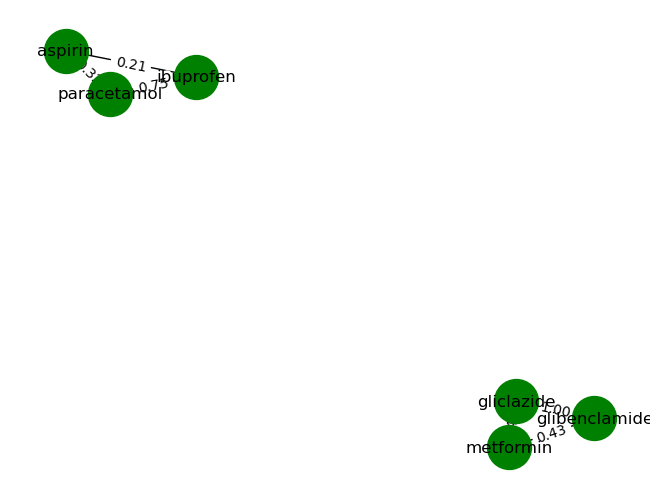

In [45]:
#a network w/ more drugs
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
drug_codes = {
    "aspirin": ["B01AC06", "N02BA01"],
    "ibuprofen": ["M01AE01", "N02BE01"],
    "metformin": ["A10BA02"],
    "glibenclamide": ["A10BB01"],
    "paracetamol": ["N02BE01"],      
    "gliclazide": ["A10BB09"]        
}
G = nx.Graph()

# Add nodes
for drug in drug_codes.keys():
    G.add_node(drug)

# edges 
drugs = list(drug_codes.keys())
for i in range(len(drugs)):
    for j in range(i+1, len(drugs)):
        sim = drug_atc_similarity(drug_codes[drugs[i]], drug_codes[drugs[j]])
        if sim > 0:  #similary greater than 0
            G.add_edge(drugs[i], drugs[j], weight=sim)

# edges&nodes
print("Nodes:", G.nodes())
print("Edges with weights:")
for u, v, d in G.edges(data=True):
    print(f"{u} - {v}: weight", d['weight'])

edge_data = []
for u, v, d in G.edges(data=True):
    edge_data.append({
        "Drug 1": u,
        "Drug 2": v,
        "ATC Similarity": d['weight']
    })

# df
df_edges = pd.DataFrame(edge_data)

# Display table
print(df_edges)

#  network
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='green', node_size=1000)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels={k: f"{v:.2f}" for k,v in labels.items()})
plt.show()